# Eksperyment: Konkatenacja embeddingów title

Zamiast uśredniać embeddingi prac danego naukowca (centroid), konkatenujemy embeddingi z różnych modeli, tworząc bogatszy profil.

**Cel:** Sprawdzić czy konkatenacja embeddingów z różnych modeli daje lepsze rozdzielenie profili naukowców.

## 1. Importy i konfiguracja

In [165]:
import pandas as pd
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

print('✅ Biblioteki załadowane')

✅ Biblioteki załadowane


In [166]:
# Ścieżki do plików
SCIENTISTS_FILE = '../data/scientists_with_identifiers.csv'
WORKS_FILE      = '../data/titles_with_abstracts.csv'
PROFILES_DIR         = '../data/embeddings/profiles'
WORK_EMBEDDINGS_DIR  = '../data/embeddings'

# Modele
MODELS = {
    'MiniLM-L6':          'all-MiniLM-L6-v2',
    'Specter':             'allenai/specter', #768
    'MPNet-Base':          'all-mpnet-base-v2', #768
    'Multilingual-MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
    'MiniLM-L12':          'all-MiniLM-L12-v2',
    'BGE-Small':           'BAAI/bge-small-en-v1.5',
}

EMB_TYPES = ['title', 'abstract']   # oba typy
MIN_WORKS = 3

print(f'📋 Konfiguracja:')
print(f'   Modele: {list(MODELS.keys())}')
print(f'   Typy embeddingów: {EMB_TYPES}')
print(f'   Min. prac naukowca: {MIN_WORKS}')

📋 Konfiguracja:
   Modele: ['MiniLM-L6', 'Specter', 'MPNet-Base', 'Multilingual-MiniLM', 'MiniLM-L12', 'BGE-Small']
   Typy embeddingów: ['title', 'abstract']
   Min. prac naukowca: 3


## 2. Wczytanie danych naukowców

In [167]:
def clean_orcid(val):
    if pd.isna(val):
        return None
    return str(val).replace('https://orcid.org/', '').replace('http://orcid.org/', '').strip()

df_scientists = pd.read_csv(SCIENTISTS_FILE)
df_works      = pd.read_csv(WORKS_FILE)

df_scientists['clean_orcid'] = df_scientists['orcid'].apply(clean_orcid)
df_works['clean_orcid']      = df_works['main_author_orcid'].apply(clean_orcid)

print(f'✅ Załadowano:')
print(f'   Naukowcy: {len(df_scientists)}')
print(f'   Prace:    {len(df_works)}')
print(f'\nKolumny naukowców: {df_scientists.columns.tolist()}')

✅ Załadowano:
   Naukowcy: 164
   Prace:    3440

Kolumny naukowców: ['profile_id', 'full_name', 'academic_title', 'first_name', 'last_name', 'position', 'profile_url', 'image_url', 'affiliations', 'orcid', 'google_scholar_id', 'google_scholar_url', 'scopus_id', 'scopus_url', 'europepmc', 'crossref', 'researchgate', 'other_links', 'clean_orcid']


In [168]:
# Filtracja: naukowcy z co najmniej MIN_WORKS pracami i tytułem
df_works_clean = df_works.dropna(subset=['clean_orcid', 'title']).copy()

works_per_scientist = df_works_clean.groupby('clean_orcid').size()
valid_orcids        = works_per_scientist[works_per_scientist >= MIN_WORKS].index.tolist()

df_works_filtered = df_works_clean[df_works_clean['clean_orcid'].isin(valid_orcids)]

orcid_to_name = dict(zip(df_scientists['clean_orcid'], df_scientists['full_name']))

print(f'✅ Po filtracji (>= {MIN_WORKS} prac):')
print(f'   Naukowcy: {len(valid_orcids)}')
print(f'   Prace:    {len(df_works_filtered)}')

✅ Po filtracji (>= 3 prac):
   Naukowcy: 107
   Prace:    3426


## PCA dla pojedynczego modelu

In [169]:
def load_profiles(model_short_name: str, emb_type: str, embeddings_dir: str):
    """Wczytuje zapisane profile (centroidy) z pliku pkl."""
    filename = f'embeddings_{model_short_name}_{emb_type}.pkl'
    filepath = os.path.join(embeddings_dir, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f'Brak pliku: {filepath}')
    with open(filepath, 'rb') as f:
        data = pickle.load(f)
    return data['profiles'], data['work_counts']


# all_profiles[(model_short, emb_type)] -> {orcid -> centroid_embedding}
# all_work_counts[(model_short, emb_type)] -> {orcid -> n_works}
all_profiles    = {}
all_work_counts = {}

for emb_type in EMB_TYPES:
    print(f'\n── {emb_type.upper()} ──────────────────────────')
    for model_short in MODELS:
        try:
            profiles, work_counts = load_profiles(model_short, emb_type, PROFILES_DIR)
            all_profiles[(model_short, emb_type)]    = profiles
            all_work_counts[(model_short, emb_type)] = work_counts
            dim = len(next(iter(profiles.values())))
            print(f'  ✅ {model_short}: {len(profiles)} profili, wymiar={dim}')
        except FileNotFoundError as e:
            print(f'  ❌ {model_short}: {e}')

print(f'\n✅ Łącznie wczytano {len(all_profiles)} konfiguracji')


── TITLE ──────────────────────────
  ✅ MiniLM-L6: 107 profili, wymiar=384
  ✅ Specter: 107 profili, wymiar=768
  ✅ MPNet-Base: 107 profili, wymiar=768
  ✅ Multilingual-MiniLM: 107 profili, wymiar=384
  ✅ MiniLM-L12: 107 profili, wymiar=384
  ✅ BGE-Small: 107 profili, wymiar=384

── ABSTRACT ──────────────────────────
  ✅ MiniLM-L6: 107 profili, wymiar=384
  ✅ Specter: 107 profili, wymiar=768
  ✅ MPNet-Base: 107 profili, wymiar=768
  ✅ Multilingual-MiniLM: 107 profili, wymiar=384
  ✅ MiniLM-L12: 107 profili, wymiar=384
  ✅ BGE-Small: 107 profili, wymiar=384

✅ Łącznie wczytano 12 konfiguracji


Model: MiniLM-L6  |  Typ: title
Naukowcy: 107, wymiar: 384
PCA wyjaśniona wariancja: PC1=17.0%, PC2=9.6%


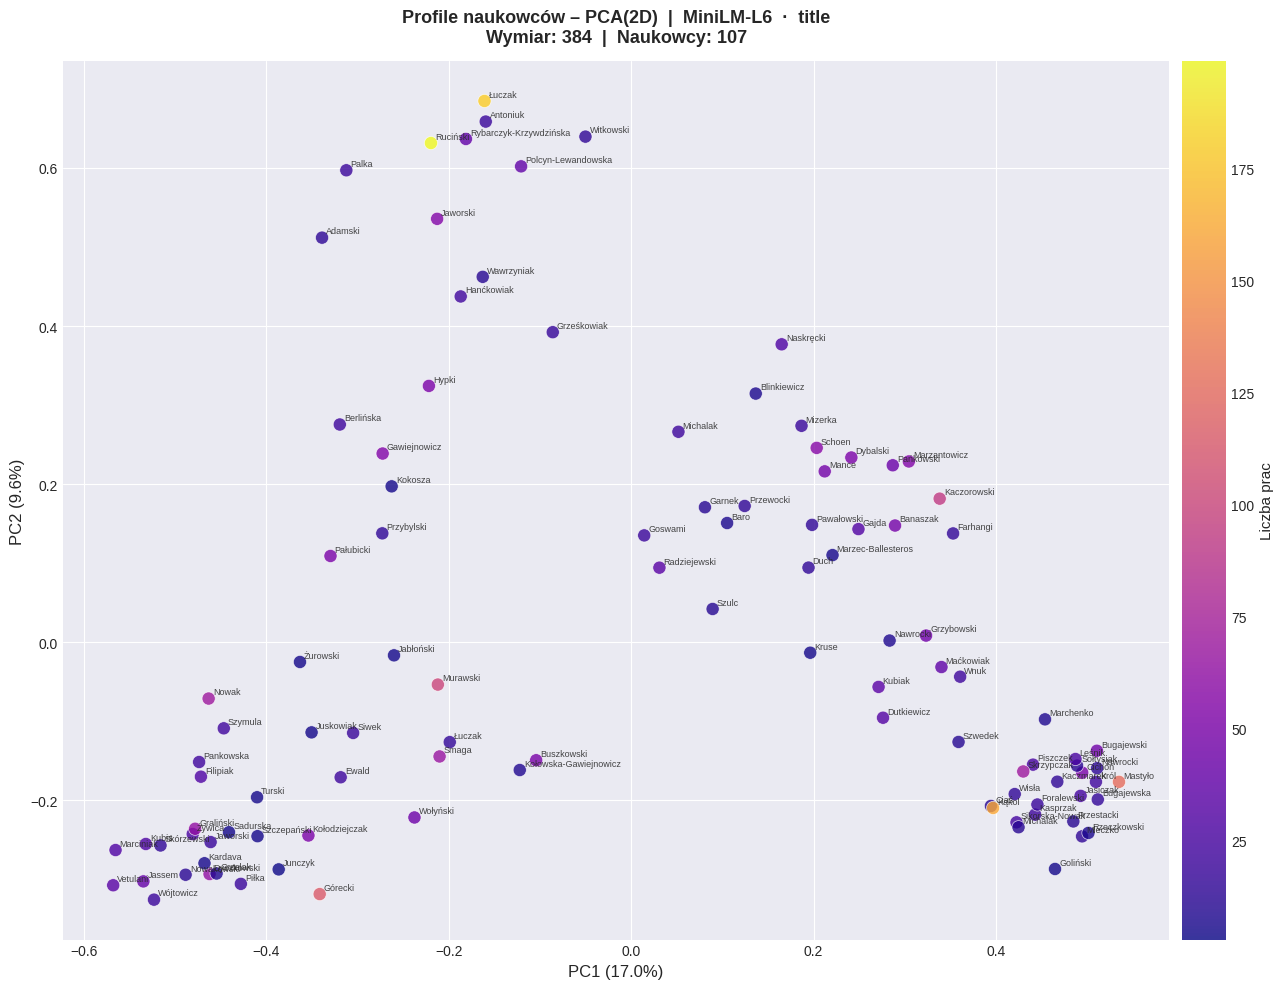

In [170]:
# ── Wybierz konfigurację ───────────────────────────────────────────────────────
SELECTED_MODEL    = 'MiniLM-L6'   # 'Specter' | 'MPNet-Base' | 'Multilingual-MiniLM'
SELECTED_EMB_TYPE = 'title'       # 'title'   | 'abstract'
# ───────────────────────────────────────────────────────────────────────────────

key         = (SELECTED_MODEL, SELECTED_EMB_TYPE)
profiles    = all_profiles[key]
work_counts = all_work_counts[key]

orcids_sel = [o for o in profiles if o in set(valid_orcids)]
matrix_sel = np.array([profiles[o] for o in orcids_sel])
names_sel  = [orcid_to_name.get(o, o) for o in orcids_sel]
counts_sel = np.array([work_counts.get(o, MIN_WORKS) for o in orcids_sel])

# PCA → 2D
pca_sel    = PCA(n_components=2, random_state=42)
coords_sel = pca_sel.fit_transform(normalize(matrix_sel, norm='l2'))
exp_sel    = pca_sel.explained_variance_ratio_ * 100

print(f'Model: {SELECTED_MODEL}  |  Typ: {SELECTED_EMB_TYPE}')
print(f'Naukowcy: {len(orcids_sel)}, wymiar: {matrix_sel.shape[1]}')
print(f'PCA wyjaśniona wariancja: PC1={exp_sel[0]:.1f}%, PC2={exp_sel[1]:.1f}%')

# Wykres
fig, ax = plt.subplots(figsize=(14, 10))

sc = ax.scatter(
    coords_sel[:, 0], coords_sel[:, 1],
    c=counts_sel, cmap='plasma',
    alpha=0.80, s=90,
    edgecolors='white', linewidths=0.5,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Liczba prac', fontsize=11)

for i, name in enumerate(names_sel):
    short = name.split()[-1] if name else orcids_sel[i][:8]
    ax.annotate(short, (coords_sel[i, 0], coords_sel[i, 1]),
                fontsize=6.5, alpha=0.85,
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({exp_sel[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({exp_sel[1]:.1f}%)', fontsize=12)
ax.set_title(
    f'Profile naukowców – PCA(2D)  |  {SELECTED_MODEL}  ·  {SELECTED_EMB_TYPE}\n'
    f'Wymiar: {matrix_sel.shape[1]}  |  Naukowcy: {len(orcids_sel)}',
    fontsize=13, fontweight='bold', pad=14
)

plt.tight_layout()
plt.show()

## Profil z konkatenacji embeddingów prac

In [192]:
# ── Wybierz dwie konfiguracje do konkatenacji ─────────────────────────────────
CONFIG_A = ('MiniLM-L6', 'title')     # (model, typ)  embedding A
CONFIG_B = ('Multilingual-MiniLM',   'title')  # (model, typ)  embedding B
# CONFIG_B = ('MPNet-Base',   'title')  # (model, typ)  embedding B

# ───────────────────────────────────────────────────────────────────────────────

# # ── Wybierz dwie konfiguracje do konkatenacji ─────────────────────────────────
# CONFIG_A = ('Specter', 'title')     # (model, typ)  embedding A
# CONFIG_B = ('MPNet-Base',   'title')  # (model, typ)  embedding B
# # ──────────────────────────────────────────────────────────────────────────────

def load_work_embedding(openalex_id: str, model_short: str, emb_type: str) -> np.ndarray | None:
    """Wczytuje embedding pojedynczej pracy z pliku per-work pkl."""
    model_norm = MODELS[model_short].replace('/', '-').replace('\\', '-')
    subdir     = 'titles' if emb_type == 'title' else 'abstracts'
    filepath   = os.path.join(WORK_EMBEDDINGS_DIR, subdir, model_norm,
                              f'{openalex_id}_{emb_type}.pkl')
    if not os.path.exists(filepath):
        return None
    with open(filepath, 'rb') as f:
        return pickle.load(f)['embedding']


model_a, type_a = CONFIG_A
model_b, type_b = CONFIG_B

print(f'Budowanie profili: [{model_a} / {type_a}] ⊕ [{model_b} / {type_b}]')
print(f'Naukowców do przetworzenia: {len(valid_orcids)}\n')

concat_profiles    = {}   # orcid -> centroid z konkatenowanych embeddingów prac
concat_work_counts = {}   # orcid -> liczba prac które miały oba embeddingi
skipped_works      = 0

for orcid in valid_orcids:
    works         = df_works_filtered[df_works_filtered['clean_orcid'] == orcid]
    work_vecs     = []

    for _, work in works.iterrows():
        wid   = work['openalex_id']
        emb_a = load_work_embedding(wid, model_a, type_a)
        emb_b = load_work_embedding(wid, model_b, type_b)

        if emb_a is None or emb_b is None:
            skipped_works += 1
            continue

        work_vecs.append(np.concatenate([emb_a, emb_b]))

    if work_vecs:
        concat_profiles[orcid]    = np.mean(work_vecs, axis=0)
        concat_work_counts[orcid] = len(work_vecs)

dim_a = len(next(iter(all_profiles[CONFIG_A].values())))
dim_b = len(next(iter(all_profiles[CONFIG_B].values())))

print(f'✅ Zbudowano {len(concat_profiles)} profili')
print(f'   Wymiar: {dim_a} + {dim_b} = {dim_a + dim_b}')
print(f'   Pominięte prace (brak jednego z embeddingów): {skipped_works}')

Budowanie profili: [MiniLM-L6 / title] ⊕ [Multilingual-MiniLM / title]
Naukowców do przetworzenia: 107

✅ Zbudowano 107 profili
   Wymiar: 384 + 384 = 768
   Pominięte prace (brak jednego z embeddingów): 0


Model A: ('MiniLM-L6', 'title')  ⊕  Model B: ('Multilingual-MiniLM', 'title')
Naukowcy: 107, wymiar: 768
PCA wyjaśniona wariancja: PC1=26.5%, PC2=8.0%


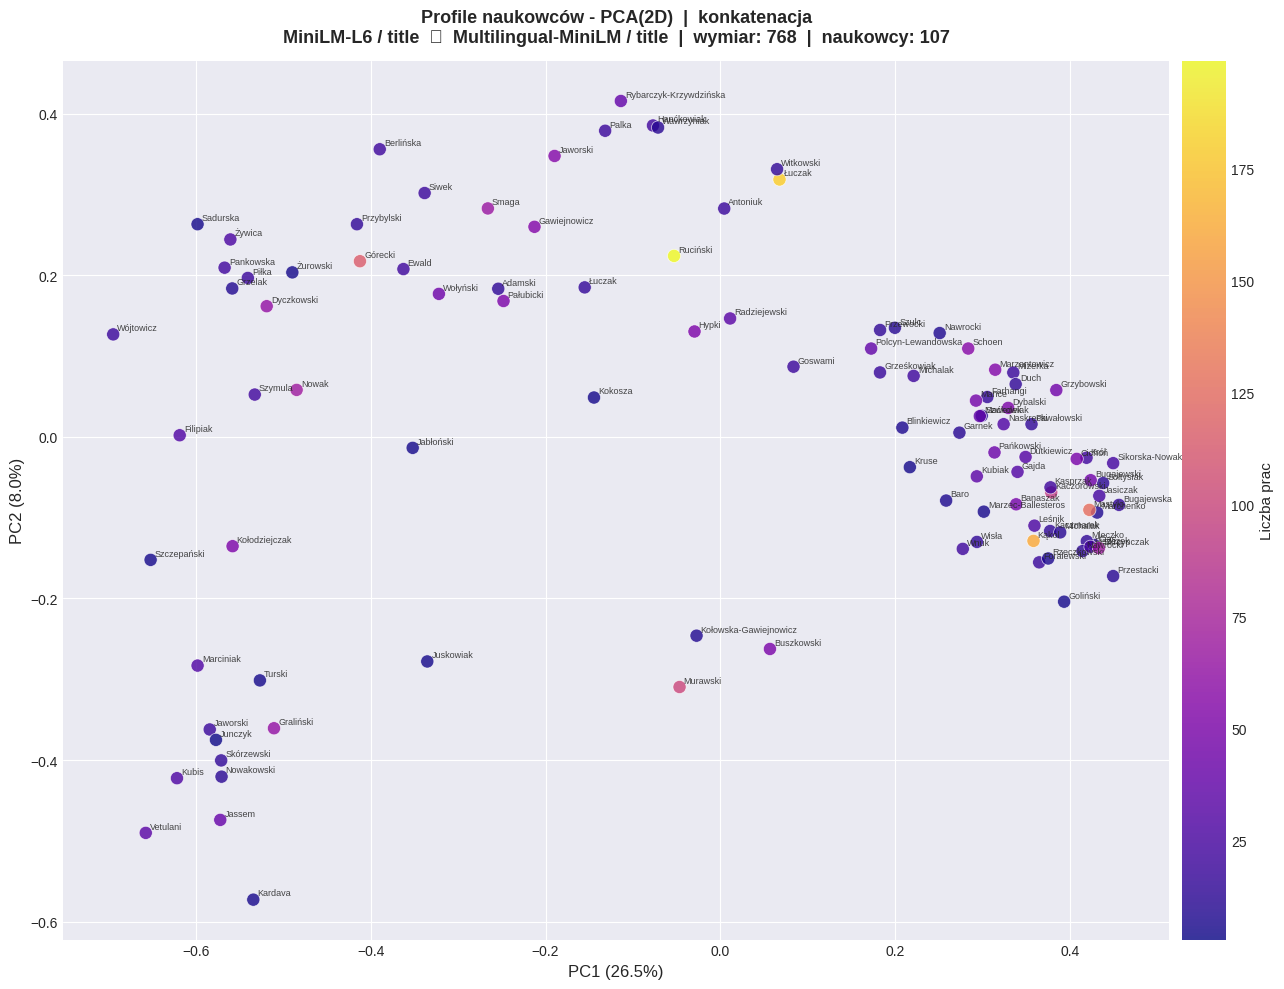

In [193]:
orcids_c  = [o for o in concat_profiles if o in set(valid_orcids)]
matrix_c  = np.array([concat_profiles[o] for o in orcids_c])
names_c   = [orcid_to_name.get(o, o) for o in orcids_c]
counts_c  = np.array([concat_work_counts.get(o, MIN_WORKS) for o in orcids_c])

pca_c    = PCA(n_components=2, random_state=42)
coords_c = pca_c.fit_transform(normalize(matrix_c, norm='l2'))
exp_c    = pca_c.explained_variance_ratio_ * 100

print(f'Model A: {CONFIG_A}  ⊕  Model B: {CONFIG_B}')
print(f'Naukowcy: {len(orcids_c)}, wymiar: {matrix_c.shape[1]}')
print(f'PCA wyjaśniona wariancja: PC1={exp_c[0]:.1f}%, PC2={exp_c[1]:.1f}%')

fig, ax = plt.subplots(figsize=(14, 10))

sc = ax.scatter(
    coords_c[:, 0], coords_c[:, 1],
    c=counts_c, cmap='plasma',
    alpha=0.80, s=90,
    edgecolors='white', linewidths=0.5,
)
cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label('Liczba prac', fontsize=11)

for i, name in enumerate(names_c):
    short = name.split()[-1] if name else orcids_c[i][:8]
    ax.annotate(short, (coords_c[i, 0], coords_c[i, 1]),
                fontsize=6.5, alpha=0.85,
                xytext=(3, 3), textcoords='offset points')

ax.set_xlabel(f'PC1 ({exp_c[0]:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({exp_c[1]:.1f}%)', fontsize=12)
ax.set_title(
    f'Profile naukowców - PCA(2D)  |  konkatenacja\n'
    f'{CONFIG_A[0]} / {CONFIG_A[1]}  ⊕  {CONFIG_B[0]} / {CONFIG_B[1]}'
    f'  |  wymiar: {matrix_c.shape[1]}  |  naukowcy: {len(orcids_c)}',
    fontsize=13, fontweight='bold', pad=14
)

plt.tight_layout()
plt.show()

In [173]:
# ── Wybierz naukowca ──────────────────────────────────────────────────────────
SEARCH_NAME = 'kubis'   # fragment nazwiska lub imienia, bez wielkości liter
# ─────────────────────────────────────────────────────────────────────────────

matches = df_scientists[
    df_scientists['full_name'].str.contains(SEARCH_NAME, case=False, na=False)
]
if matches.empty:
    print(f'❌ Nie znaleziono naukowca: "{SEARCH_NAME}"')
else:
    print(f'Znaleziono {len(matches)} wynik(ów):')
    for _, r in matches.iterrows():
        print(f'  {r["full_name"]}  |  {r["clean_orcid"]}')

Znaleziono 1 wynik(ów):
  dr Marek Kubis  |  0000-0002-2016-2598


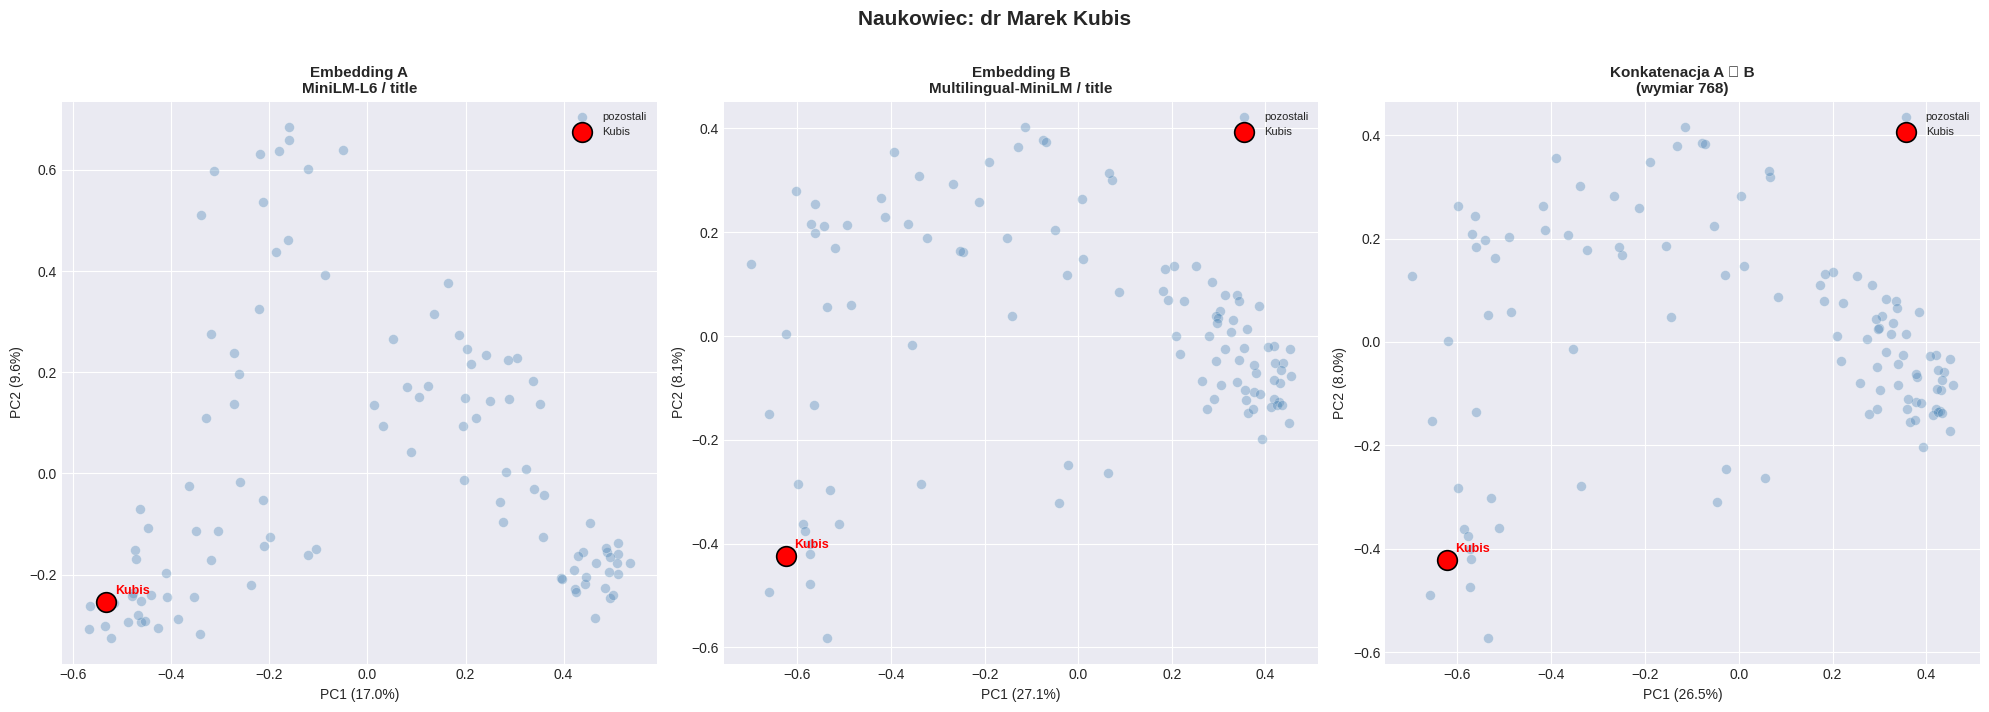


📊 Statystyki embeddingów: dr Marek Kubis
                                      Embedding A        Embedding B       Konkatenacja
--------------------------------------------------------------------------------------
  Wymiar                                      384                384                768
  Średnia                                  0.0006            -0.0002             0.0002
  Std                                      0.0276             0.1362             0.0982
  Min                                     -0.0817            -0.4238            -0.4238
  Max                                      0.0818             0.4678             0.4678


In [174]:
SEL_ORCID = matches.iloc[0]['clean_orcid']   # zmień indeks jeśli znaleziono kilka
SEL_NAME  = orcid_to_name.get(SEL_ORCID, SEL_ORCID)

if SEL_ORCID not in concat_profiles:
    print(f'❌ {SEL_NAME} nie ma profilu (za mało prac lub brak embeddingów)')
else:
    # ── Oblicz PCA dla każdej z 3 przestrzeni ────────────────────────────────

    def make_pca_space(profiles_dict, orcids_order):
        mat = np.array([profiles_dict[o] for o in orcids_order])
        pca = PCA(n_components=2, random_state=42)
        coords = pca.fit_transform(normalize(mat, norm='l2'))
        exp    = pca.explained_variance_ratio_ * 100
        return coords, exp

    # wspólna kolejność naukowców (tylko ci którzy mają wszystkie 3 profile)
    common = [o for o in orcids_c]   # orcids_c pochodzi z komórki PCA konkatenacji

    coords_a, exp_a = make_pca_space(all_profiles[CONFIG_A], common)
    coords_b, exp_b = make_pca_space(all_profiles[CONFIG_B], common)
    # coords_c i exp_c już są z poprzedniej komórki, ale liczymy na tym samym zbiorze
    coords_cc, exp_cc = make_pca_space(concat_profiles, common)

    sel_idx = common.index(SEL_ORCID)

    # ── Wykres 3 × PCA ───────────────────────────────────────────────────────
    configs_plot = [
        (coords_a,  exp_a,  f'Embedding A\n{CONFIG_A[0]} / {CONFIG_A[1]}'),
        (coords_b,  exp_b,  f'Embedding B\n{CONFIG_B[0]} / {CONFIG_B[1]}'),
        (coords_cc, exp_cc, f'Konkatenacja A ⊕ B\n(wymiar {matrix_c.shape[1]})'),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(f'Naukowiec: {SEL_NAME}', fontsize=15, fontweight='bold', y=1.01)

    for ax, (coords, exp, title) in zip(axes, configs_plot):
        names_here = [orcid_to_name.get(o, o) for o in common]

        # tło – pozostali naukowcy
        ax.scatter(coords[:, 0], coords[:, 1],
                   c='steelblue', alpha=0.35, s=50,
                   edgecolors='white', linewidths=0.4, label='pozostali')

        # wybrany naukowiec
        ax.scatter(coords[sel_idx, 0], coords[sel_idx, 1],
                   c='red', s=200, zorder=5,
                   edgecolors='black', linewidths=1.2, label=SEL_NAME.split()[-1])

        ax.annotate(SEL_NAME.split()[-1],
                    (coords[sel_idx, 0], coords[sel_idx, 1]),
                    fontsize=9, fontweight='bold', color='red',
                    xytext=(6, 6), textcoords='offset points')

        ax.set_xlabel(f'PC1 ({exp[0]:.1f}%)', fontsize=10)
        ax.set_ylabel(f'PC2 ({exp[1]:.1f}%)', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()

    # ── Wartości embeddingów (statystyki) ────────────────────────────────────
    emb_a_sel = all_profiles[CONFIG_A][SEL_ORCID]
    emb_b_sel = all_profiles[CONFIG_B][SEL_ORCID]
    emb_c_sel = concat_profiles[SEL_ORCID]

    print(f'\n📊 Statystyki embeddingów: {SEL_NAME}')
    print(f'{"":30} {"Embedding A":>18} {"Embedding B":>18} {"Konkatenacja":>18}')
    print('-' * 86)
    for label, vec in [('Wymiar',   None),
                       ('Średnia',  None),
                       ('Std',      None),
                       ('Min',      None),
                       ('Max',      None)]:
        if label == 'Wymiar':
            vals = [len(emb_a_sel), len(emb_b_sel), len(emb_c_sel)]
            print(f'  {label:<28} {vals[0]:>18} {vals[1]:>18} {vals[2]:>18}')
        elif label == 'Średnia':
            vals = [emb_a_sel.mean(), emb_b_sel.mean(), emb_c_sel.mean()]
            print(f'  {label:<28} {vals[0]:>18.4f} {vals[1]:>18.4f} {vals[2]:>18.4f}')
        elif label == 'Std':
            vals = [emb_a_sel.std(), emb_b_sel.std(), emb_c_sel.std()]
            print(f'  {label:<28} {vals[0]:>18.4f} {vals[1]:>18.4f} {vals[2]:>18.4f}')
        elif label == 'Min':
            vals = [emb_a_sel.min(), emb_b_sel.min(), emb_c_sel.min()]
            print(f'  {label:<28} {vals[0]:>18.4f} {vals[1]:>18.4f} {vals[2]:>18.4f}')
        elif label == 'Max':
            vals = [emb_a_sel.max(), emb_b_sel.max(), emb_c_sel.max()]
            print(f'  {label:<28} {vals[0]:>18.4f} {vals[1]:>18.4f} {vals[2]:>18.4f}')

In [175]:
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print(f'═══ Embedding A  [{CONFIG_A[0]} / {CONFIG_A[1]}]  (dim={len(emb_a_sel)}) ═══')
print(emb_a_sel)

print(f'\n═══ Embedding B  [{CONFIG_B[0]} / {CONFIG_B[1]}]  (dim={len(emb_b_sel)}) ═══')
print(emb_b_sel)

print(f'\n═══ Konkatenacja A ⊕ B  (dim={len(emb_c_sel)}) ═══')
print(emb_c_sel)

═══ Embedding A  [MiniLM-L6 / title]  (dim=384) ═══
[-0.0374 -0.0329  0.0094 -0.0087 -0.0132  0.0127  0.0327 -0.0285 -0.0183 -0.0043  0.0039 -0.0108  0.0431  0.0281
 -0.0194  0.0246  0.0281  0.0507 -0.0321 -0.0436  0.0172  0.0597  0.0279 -0.0043  0.0397 -0.0146 -0.0389 -0.003
  0.0152 -0.0215 -0.0033  0.0428  0.034   0.0458  0.0222  0.0056  0.0094  0.0071 -0.0096 -0.0089 -0.0155 -0.0183
 -0.0051  0.0238  0.0376 -0.009  -0.0435  0.0208 -0.0093  0.0257 -0.0698 -0.0207 -0.0087  0.0221 -0.0129  0.0214
 -0.0034  0.0329 -0.0231 -0.0457 -0.0082 -0.0477 -0.0635  0.0204  0.0079  0.0058 -0.0055  0.0221 -0.0071  0.0031
 -0.0273  0.0362 -0.0416  0.0469 -0.0107  0.0303  0.0219 -0.0215  0.0125 -0.0458  0.0081 -0.0204  0.022   0.0118
  0.0433 -0.0062  0.0215  0.0032  0.0074  0.0084 -0.0394 -0.0631  0.0711  0.0009 -0.0044  0.0261  0.0345 -0.0328
  0.0234  0.0818 -0.0051  0.0136  0.0171 -0.055  -0.0379 -0.0204  0.0199 -0.0203  0.0202 -0.0415 -0.0175 -0.0076
 -0.0096 -0.0236  0.0456 -0.055   0.001  -0.0

In [176]:
from sklearn.metrics.pairwise import cosine_similarity

def top_k_neighbors(sel_orcid, profiles_dict, orcids_order, k=10):
    """Zwraca top-k sąsiadów dla wybranego naukowca na podstawie cosine similarity."""
    mat  = np.array([profiles_dict[o] for o in orcids_order])
    sel  = profiles_dict[sel_orcid].reshape(1, -1)
    sims = cosine_similarity(sel, mat)[0]

    ranked = sorted(
        ((orcids_order[i], sims[i]) for i in range(len(orcids_order)) if orcids_order[i] != sel_orcid),
        key=lambda x: x[1], reverse=True
    )
    return ranked[:k]


neighbors_a = top_k_neighbors(SEL_ORCID, all_profiles[CONFIG_A], common)
neighbors_b = top_k_neighbors(SEL_ORCID, all_profiles[CONFIG_B], common)
neighbors_c = top_k_neighbors(SEL_ORCID, concat_profiles,        common)

# ── Wyświetlenie ─────────────────────────────────────────────────────────────
col_w = 42

header_a = f'A: {CONFIG_A[0]} / {CONFIG_A[1]}'
header_b = f'B: {CONFIG_B[0]} / {CONFIG_B[1]}'
header_c = f'Konkatenacja A ⊕ B'

print(f'Top-10 najbliższych naukowców: {SEL_NAME}\n')
print(f'{"#":<4} {header_a:<{col_w}} {header_b:<{col_w}} {header_c:<{col_w}}')
print('─' * (4 + col_w * 3))

for i in range(10):
    rank = f'{i+1}.'

    name_a, sim_a = neighbors_a[i]
    name_b, sim_b = neighbors_b[i]
    name_c, sim_c = neighbors_c[i]

    cell_a = f'{orcid_to_name.get(name_a, name_a)[:32]}  ({sim_a:.3f})'
    cell_b = f'{orcid_to_name.get(name_b, name_b)[:32]}  ({sim_b:.3f})'
    cell_c = f'{orcid_to_name.get(name_c, name_c)[:32]}  ({sim_c:.3f})'

    print(f'{rank:<4} {cell_a:<{col_w}} {cell_b:<{col_w}} {cell_c:<{col_w}}')

# ── Różnice między przestrzeniami ────────────────────────────────────────────
set_a = {o for o, _ in neighbors_a}
set_b = {o for o, _ in neighbors_b}
set_c = {o for o, _ in neighbors_c}

print(f'\nNakładanie się sąsiadów (Jaccard):')
def jaccard(s1, s2): return len(s1 & s2) / len(s1 | s2)
print(f'  A ∩ B / A ∪ B  = {jaccard(set_a, set_b):.3f}   '
      f'(wspólnych: {len(set_a & set_b)}/10)')
print(f'  A ∩ C / A ∪ C  = {jaccard(set_a, set_c):.3f}   '
      f'(wspólnych: {len(set_a & set_c)}/10)')
print(f'  B ∩ C / B ∪ C  = {jaccard(set_b, set_c):.3f}   '
      f'(wspólnych: {len(set_b & set_c)}/10)')

Top-10 najbliższych naukowców: dr Marek Kubis

#    A: MiniLM-L6 / title                       B: Multilingual-MiniLM / title             Konkatenacja A ⊕ B                        
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1.   dr Paweł Marek Skórzewski  (0.887)         dr Paweł Marek Skórzewski  (0.902)         dr Paweł Marek Skórzewski  (0.901)        
2.   prof. UAM dr hab. Filip Gralińsk  (0.852)  prof. dr hab. Zygmunt Vetulani  (0.885)    prof. dr hab. Zygmunt Vetulani  (0.882)   
3.   prof. UAM dr hab. Krzysztof Jass  (0.842)  prof. UAM dr hab. Filip Gralińsk  (0.880)  prof. UAM dr hab. Filip Gralińsk  (0.879) 
4.   prof. dr hab. Zygmunt Vetulani  (0.825)    prof. UAM dr hab. Krzysztof Jass  (0.868)  prof. UAM dr hab. Krzysztof Jass  (0.867) 
5.   dr inż. Artur Adam Nowakowski  (0.750)     dr Rafał Tomasz Jaworski  (0.817)          dr Rafał Tomasz Jaworski  (0.814)         
6.   dr Rafał Toma

In [177]:
# Cache macierzy projekcji – ta sama para (input_dim, target_dim) zawsze da
# identyczną macierz, dzięki czemu wyniki są powtarzalne między wywołaniami.
_projection_cache: dict = {}

def resize_embedding(embedding: np.ndarray, target_dim: int, seed: int = 42) -> np.ndarray:
    """
    Zmienia wymiar embeddingu przez losową projekcję liniową (Johnson - Lindenstrauss)
    i normalizuje wynik L2.

    Działa w obie strony:
      - redukcja:  input_dim > target_dim  (np. 768 → 384)
      - ekspansja: input_dim < target_dim  (np. 384 → 768)
      - bez zmian: input_dim == target_dim → tylko normalizacja

    Macierz projekcji jest deterministyczna (stały seed + wymiary), więc
    ten sam embedding zawsze daje ten sam wynik.

    Args:
        embedding:  Wektor wejściowy (1D numpy array)
        target_dim: Docelowy wymiar wyjściowy
        seed:       Ziarno losowości (domyślnie 42)

    Returns:
        Znormalizowany wektor numpy o kształcie (target_dim,)
    """
    embedding = np.asarray(embedding, dtype=np.float32)
    input_dim = embedding.shape[0]

    if input_dim == target_dim:
        norm = np.linalg.norm(embedding)
        return embedding / norm if norm > 0 else embedding

    cache_key = (input_dim, target_dim, seed)
    if cache_key not in _projection_cache:
        rng = np.random.RandomState(seed + input_dim * 100_000 + target_dim)
        # Skalowanie 1/sqrt(target_dim) zachowuje przybliżone normy (JL lemma)
        _projection_cache[cache_key] = rng.randn(input_dim, target_dim).astype(np.float32) \
                                        / np.sqrt(target_dim)

    projected = embedding @ _projection_cache[cache_key]

    norm = np.linalg.norm(projected)
    return projected / norm if norm > 0 else projected


# ── Szybki test ──────────────────────────────────────────────────────────────
_v = np.random.randn(768).astype(np.float32)

for _dim in [384, 256, 128, 768, 1024]:
    _out = resize_embedding(_v, _dim)
    print(f'  768 → {_dim:>4}:  shape={_out.shape}  '
          f'norm={np.linalg.norm(_out):.4f}  '
          f'mean={_out.mean():.4f}  std={_out.std():.4f}')

print('\n✅ resize_embedding gotowa')

  768 →  384:  shape=(384,)  norm=1.0000  mean=0.0004  std=0.0510
  768 →  256:  shape=(256,)  norm=1.0000  mean=0.0056  std=0.0622
  768 →  128:  shape=(128,)  norm=1.0000  mean=-0.0091  std=0.0879
  768 →  768:  shape=(768,)  norm=1.0000  mean=-0.0010  std=0.0361
  768 → 1024:  shape=(1024,)  norm=1.0000  mean=0.0003  std=0.0312

✅ resize_embedding gotowa


In [178]:
# ── Wymiar docelowy ────────────────────────────────────────────────────────────
TARGET_DIM = 384
# ───────────────────────────────────────────────────────────────────────────────
# Projekcja liniowa jest operacją liniową, więc:
#   resize(mean(x_i)) == mean(resize(x_i))
# Możemy więc resize'ować gotowe centroidy – wynik jest identyczny z liczeniem
# centroidu z resize'owanych embeddingów poszczególnych prac.

resized_added = []

for (model, emb_type), profiles in list(all_profiles.items()):
    dim = len(next(iter(profiles.values())))

    if dim == TARGET_DIM:
        continue  # już właściwy wymiar, nic do roboty

    new_key = (f'{model}_r{TARGET_DIM}', emb_type)

    all_profiles[new_key]    = {
        orcid: resize_embedding(vec, TARGET_DIM)
        for orcid, vec in profiles.items()
    }
    all_work_counts[new_key] = all_work_counts[(model, emb_type)]

    resized_added.append((model, emb_type, dim, new_key))

print(f'Resize embeddingów → {TARGET_DIM} dim\n')
print(f'  {"Oryginał":<30} {"Dim":>6}   {"Nowy klucz":<35} {"Dim po":>6}')
print('  ' + '─' * 80)
for model, emb_type, dim, new_key in resized_added:
    print(f'  {model} / {emb_type:<15} {dim:>6}   {str(new_key):<35} {TARGET_DIM:>6}')

print(f'\n✅ Dodano {len(resized_added)} nowych konfiguracji do all_profiles')
print(f'   Łącznie konfiguracji: {len(all_profiles)}')

Resize embeddingów → 384 dim

  Oryginał                          Dim   Nowy klucz                          Dim po
  ────────────────────────────────────────────────────────────────────────────────
  Specter / title              768   ('Specter_r384', 'title')              384
  MPNet-Base / title              768   ('MPNet-Base_r384', 'title')           384
  Specter / abstract           768   ('Specter_r384', 'abstract')           384
  MPNet-Base / abstract           768   ('MPNet-Base_r384', 'abstract')        384

✅ Dodano 4 nowych konfiguracji do all_profiles
   Łącznie konfiguracji: 16


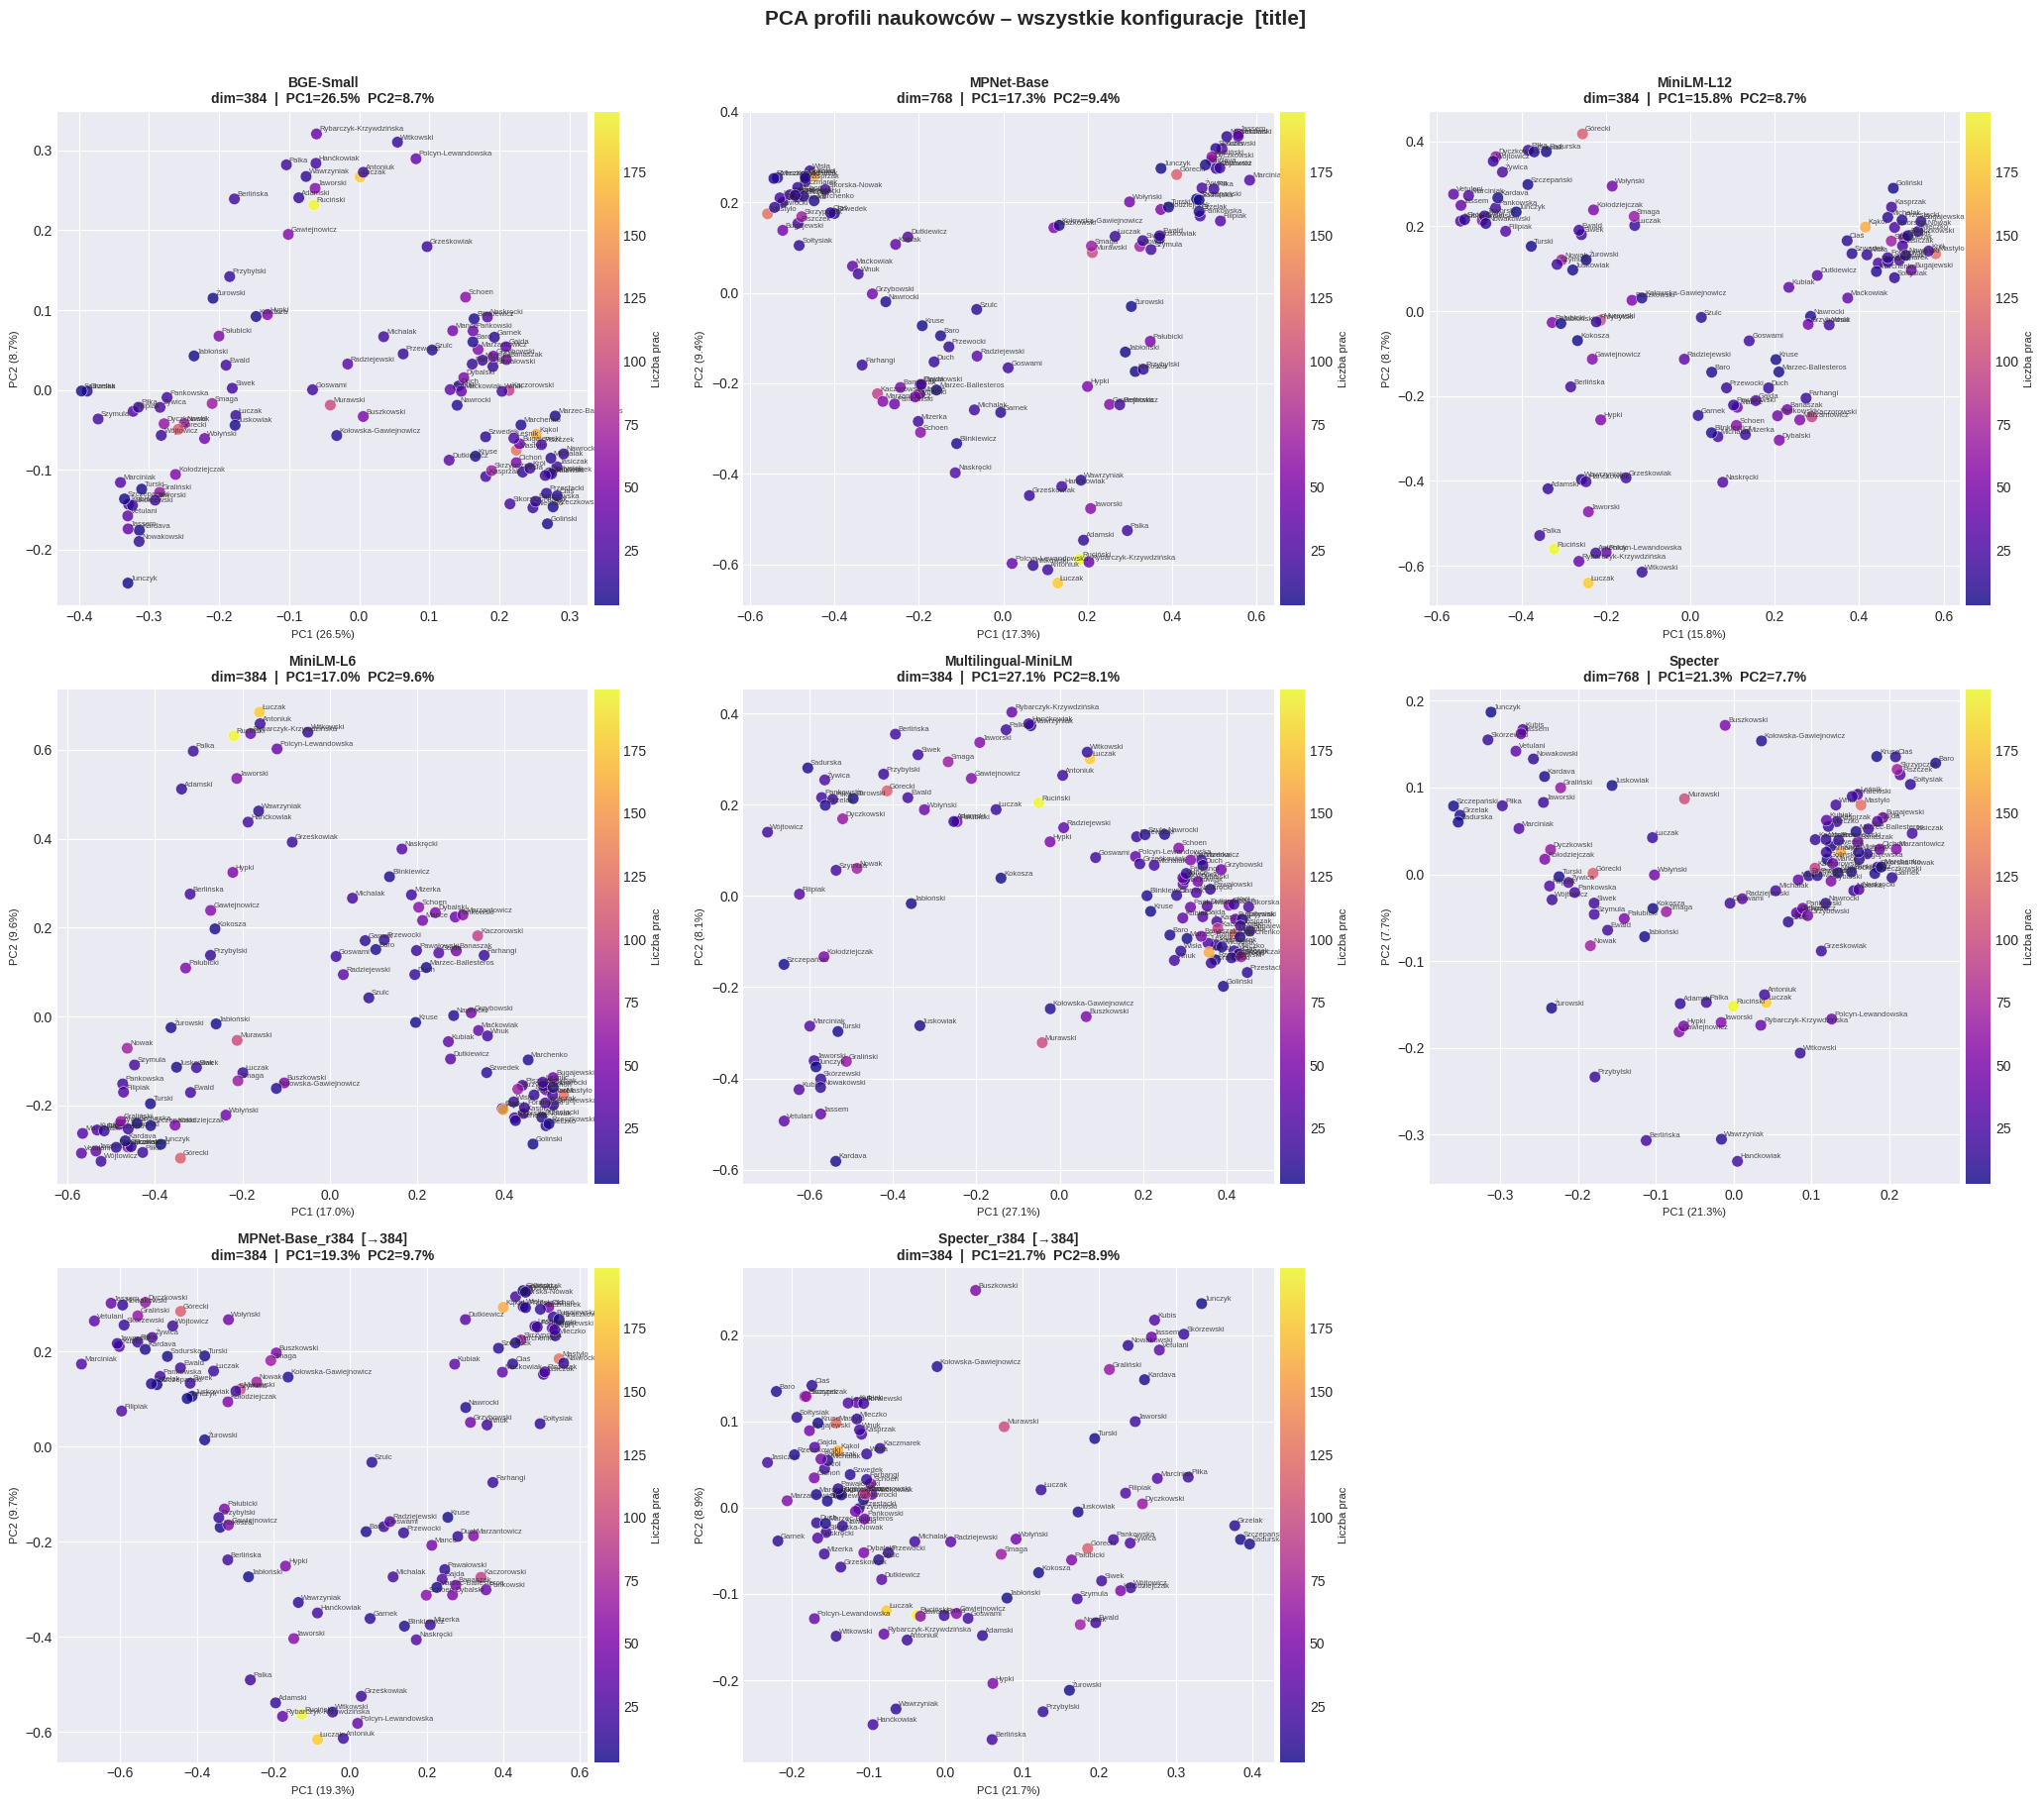

✅ Zapisano: pca_all_title.png  (8 konfiguracji)


In [179]:
import math

PLOT_EMB_TYPE = 'title'

# Wszystkie konfiguracje z danym typem, w kolejności: najpierw oryginalne, potem resized
title_keys = [k for k in all_profiles if k[1] == PLOT_EMB_TYPE]
title_keys_orig   = sorted([k for k in title_keys if '_r' not in k[0]])
title_keys_resized = sorted([k for k in title_keys if '_r' in k[0]])
title_keys = title_keys_orig + title_keys_resized

n      = len(title_keys)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
axes = np.array(axes).reshape(-1)   # zawsze 1D

for ax, key in zip(axes, title_keys):
    model, emb_type = key
    profiles   = all_profiles[key]
    wc         = all_work_counts[key]

    orcids = [o for o in profiles if o in set(valid_orcids)]
    mat    = np.array([profiles[o] for o in orcids])
    counts = np.array([wc.get(o, MIN_WORKS) for o in orcids])
    names  = [orcid_to_name.get(o, o) for o in orcids]

    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(normalize(mat, norm='l2'))
    exp    = pca.explained_variance_ratio_ * 100

    sc = ax.scatter(coords[:, 0], coords[:, 1],
                    c=counts, cmap='plasma',
                    alpha=0.80, s=70,
                    edgecolors='white', linewidths=0.4)
    plt.colorbar(sc, ax=ax, pad=0.01).set_label('Liczba prac', fontsize=8)

    for i, name in enumerate(names):
        ax.annotate(name.split()[-1], (coords[i, 0], coords[i, 1]),
                    fontsize=5.5, alpha=0.8,
                    xytext=(2, 2), textcoords='offset points')

    dim = mat.shape[1]
    resized_mark = f'  [→{TARGET_DIM}]' if '_r' in model else ''
    ax.set_title(f'{model}{resized_mark}\ndim={dim}  |  PC1={exp[0]:.1f}%  PC2={exp[1]:.1f}%',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel(f'PC1 ({exp[0]:.1f}%)', fontsize=8)
    ax.set_ylabel(f'PC2 ({exp[1]:.1f}%)', fontsize=8)

# Ukryj puste subploty (jeśli n nie jest wielokrotnością n_cols)
for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle(f'PCA profili naukowców – wszystkie konfiguracje  [{PLOT_EMB_TYPE}]',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(f'✅ Zapisano: pca_all_{PLOT_EMB_TYPE}.png  ({n} konfiguracji)')

# Remove over/under sized embeddings

In [180]:
removed = {}

for key in list(all_profiles.keys()):
    dim = len(next(iter(all_profiles[key].values())))
    if dim != TARGET_DIM:
        removed[key] = dim
        del all_profiles[key]
        del all_work_counts[key]

print(f'Usunięto {len(removed)} konfiguracji z wymiarem != {TARGET_DIM}:')
for key, dim in removed.items():
    print(f'  ✗  {key}  (dim={dim})')

print(f'\nPozostało {len(all_profiles)} konfiguracji (wszystkie dim={TARGET_DIM}):')
for key in all_profiles:
    print(f'  ✓  {key}')

Usunięto 4 konfiguracji z wymiarem != 384:
  ✗  ('Specter', 'title')  (dim=768)
  ✗  ('MPNet-Base', 'title')  (dim=768)
  ✗  ('Specter', 'abstract')  (dim=768)
  ✗  ('MPNet-Base', 'abstract')  (dim=768)

Pozostało 12 konfiguracji (wszystkie dim=384):
  ✓  ('MiniLM-L6', 'title')
  ✓  ('Multilingual-MiniLM', 'title')
  ✓  ('MiniLM-L12', 'title')
  ✓  ('BGE-Small', 'title')
  ✓  ('MiniLM-L6', 'abstract')
  ✓  ('Multilingual-MiniLM', 'abstract')
  ✓  ('MiniLM-L12', 'abstract')
  ✓  ('BGE-Small', 'abstract')
  ✓  ('Specter_r384', 'title')
  ✓  ('MPNet-Base_r384', 'title')
  ✓  ('Specter_r384', 'abstract')
  ✓  ('MPNet-Base_r384', 'abstract')


In [181]:
# ── Wybierz typ embeddingów do analizy ────────────────────────────────────────
ANALYSIS_EMB_TYPE = 'title'   # 'title' | 'abstract'
# ─────────────────────────────────────────────────────────────────────────────

profiles_for_analysis    = {k: v for k, v in all_profiles.items()    if k[1] == ANALYSIS_EMB_TYPE}
workcounts_for_analysis  = {k: v for k, v in all_work_counts.items() if k[1] == ANALYSIS_EMB_TYPE}

print(f'Konfiguracje do analizy [{ANALYSIS_EMB_TYPE}]:')
for k in profiles_for_analysis:
    dim = len(next(iter(profiles_for_analysis[k].values())))
    print(f'  ✓  {k[0]:<30}  dim={dim}')

Konfiguracje do analizy [title]:
  ✓  MiniLM-L6                       dim=384
  ✓  Multilingual-MiniLM             dim=384
  ✓  MiniLM-L12                      dim=384
  ✓  BGE-Small                       dim=384
  ✓  Specter_r384                    dim=384
  ✓  MPNet-Base_r384                 dim=384


✅ Obliczono top-10 sąsiadów dla 6 konfiguracji [title]


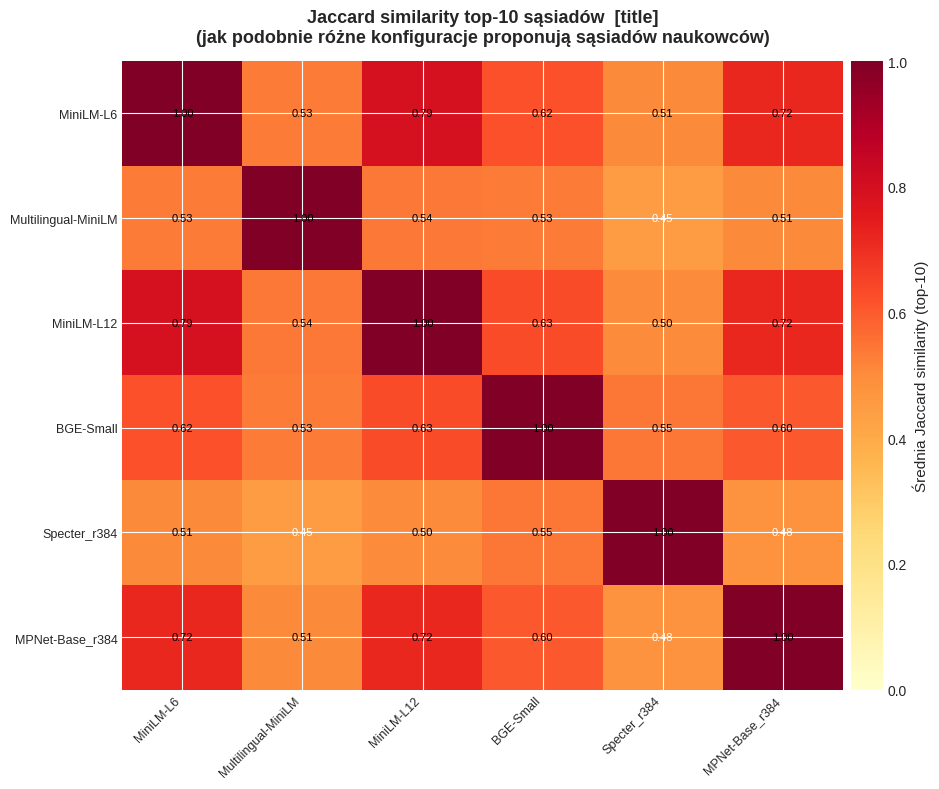

✅ Zapisano: ../results/wmi_authors/jaccard_heatmap_title.png


In [182]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

K = 10

# ── 1. Top-K sąsiedzi dla każdej konfiguracji ────────────────────────────────
all_neighbors = {}

for key, profiles in profiles_for_analysis.items():
    orcids = [o for o in profiles if o in set(valid_orcids)]
    mat    = np.array([profiles[o] for o in orcids])
    sim    = cos_sim(mat)

    neighbors = {}
    for i, orcid in enumerate(orcids):
        row = sim[i].copy()
        row[i] = -1
        top_idx = np.argsort(row)[::-1][:K]
        neighbors[orcid] = [orcids[j] for j in top_idx]

    all_neighbors[key] = neighbors

print(f'✅ Obliczono top-{K} sąsiadów dla {len(all_neighbors)} konfiguracji [{ANALYSIS_EMB_TYPE}]')

# ── 2. Pairwise Jaccard między konfiguracjami ─────────────────────────────────
keys   = list(all_neighbors.keys())
n      = len(keys)
matrix = np.zeros((n, n))

for i, k1 in enumerate(keys):
    for j, k2 in enumerate(keys):
        if i == j:
            matrix[i, j] = 1.0
            continue
        common_orcids = set(all_neighbors[k1]) & set(all_neighbors[k2])
        jaccards = []
        for orcid in common_orcids:
            s1 = set(all_neighbors[k1][orcid])
            s2 = set(all_neighbors[k2][orcid])
            union = s1 | s2
            jaccards.append(len(s1 & s2) / len(union) if union else 0)
        matrix[i, j] = np.mean(jaccards) if jaccards else 0

# ── 3. Heatmapa ──────────────────────────────────────────────────────────────
labels = [m for m, t in keys]

fig, ax = plt.subplots(figsize=(max(10, n * 1.2), max(8, n * 1.0)))

im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
cbar = plt.colorbar(im, ax=ax, pad=0.01)
cbar.set_label(f'Średnia Jaccard similarity (top-{K})', fontsize=11)

ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)

for i in range(n):
    for j in range(n):
        color = 'white' if matrix[i, j] < 0.5 else 'black'
        ax.text(j, i, f'{matrix[i, j]:.2f}', ha='center', va='center',
                fontsize=8, color=color)

ax.set_title(f'Jaccard similarity top-{K} sąsiadów  [{ANALYSIS_EMB_TYPE}]\n'
             f'(jak podobnie różne konfiguracje proponują sąsiadów naukowców)',
             fontsize=13, fontweight='bold', pad=14)

plt.tight_layout()
heatmap_path = f'../results/wmi_authors/jaccard_heatmap_{ANALYSIS_EMB_TYPE}.png'
plt.savefig(heatmap_path, dpi=130, bbox_inches='tight')
plt.show()
print(f'✅ Zapisano: {heatmap_path}')

## Konkatenacja par – porównanie Jaccard

In [183]:
# ── Pary do konkatenacji ───────────────────────────────────────────────────────
# Tylko unikalne pary (A⊕B == B⊕A) – górny trójkąt macierzy 6×6
# Odkomentuj te które chcesz zbadać

CONCAT_PAIRS = [
    #── MiniLM-L6 ──────────────────────────────────────────────────────────
    ('MiniLM-L6',       'MiniLM-L12'),
    ('MiniLM-L6',       'BGE-Small'),
    ('MiniLM-L6',       'Specter_r384'),
    ('MiniLM-L6',       'MPNet-Base_r384'),
    ('MiniLM-L6',       'Multilingual-MiniLM'),

    #── MiniLM-L12 ─────────────────────────────────────────────────────────
    ('MiniLM-L12',      'BGE-Small'),
    ('MiniLM-L12',      'Specter_r384'),
    ('MiniLM-L12',      'MPNet-Base_r384'),
    ('MiniLM-L12',      'Multilingual-MiniLM'),

    #── BGE-Small ──────────────────────────────────────────────────────────
    ('BGE-Small',       'Specter_r384'),
    ('BGE-Small',       'MPNet-Base_r384'),
    ('BGE-Small',       'Multilingual-MiniLM'),

    #── Specter_r384 ───────────────────────────────────────────────────────
    ('Specter_r384',    'MPNet-Base_r384'),
    ('Specter_r384',    'Multilingual-MiniLM'),

    #── MPNet-Base_r384 ────────────────────────────────────────────────────
    ('MPNet-Base_r384', 'Multilingual-MiniLM'),

    #── Multilingual-MiniLM ────────────────────────────────────────────────
]

print(f'Aktywnych par: {len(CONCAT_PAIRS)}')
for a, b in CONCAT_PAIRS:
    print(f'  {a}  ⊕  {b}')

Aktywnych par: 15
  MiniLM-L6  ⊕  MiniLM-L12
  MiniLM-L6  ⊕  BGE-Small
  MiniLM-L6  ⊕  Specter_r384
  MiniLM-L6  ⊕  MPNet-Base_r384
  MiniLM-L6  ⊕  Multilingual-MiniLM
  MiniLM-L12  ⊕  BGE-Small
  MiniLM-L12  ⊕  Specter_r384
  MiniLM-L12  ⊕  MPNet-Base_r384
  MiniLM-L12  ⊕  Multilingual-MiniLM
  BGE-Small  ⊕  Specter_r384
  BGE-Small  ⊕  MPNet-Base_r384
  BGE-Small  ⊕  Multilingual-MiniLM
  Specter_r384  ⊕  MPNet-Base_r384
  Specter_r384  ⊕  Multilingual-MiniLM
  MPNet-Base_r384  ⊕  Multilingual-MiniLM


In [184]:
# Budowanie profili konkatenowanych dla każdej aktywnej pary.
#
# Ponieważ konkatenacja i uśrednianie są operacjami liniowymi:
#   mean(concat(a_i, b_i)) == concat(mean(a_i), mean(b_i))
# możemy bezpośrednio konkatenować gotowe centroidy zamiast wracać do per-work pkl.

concat_pair_profiles    = {}   # label -> {orcid -> concat_centroid}
concat_pair_workcounts  = {}

for model_a, model_b in CONCAT_PAIRS:
    key_a = (model_a, ANALYSIS_EMB_TYPE)
    key_b = (model_b, ANALYSIS_EMB_TYPE)

    if key_a not in profiles_for_analysis:
        print(f'⚠️  Brak konfiguracji: {key_a}'); continue
    if key_b not in profiles_for_analysis:
        print(f'⚠️  Brak konfiguracji: {key_b}'); continue

    pa, pb   = profiles_for_analysis[key_a], profiles_for_analysis[key_b]
    common   = set(pa) & set(pb) & set(valid_orcids)

    label    = f'{model_a}⊕{model_b}'
    dim_a    = len(next(iter(pa.values())))
    dim_b    = len(next(iter(pb.values())))

    concat_pair_profiles[label]   = {
        o: np.concatenate([pa[o], pb[o]]) for o in common
    }
    concat_pair_workcounts[label] = {
        o: min(all_work_counts[key_a].get(o, 0),
               all_work_counts[key_b].get(o, 0))
        for o in common
    }

    print(f'✅  {label:<50}  naukowcy={len(common)}  dim={dim_a}+{dim_b}={dim_a+dim_b}')

print(f'\nŁącznie zbudowano {len(concat_pair_profiles)} profili par')

✅  MiniLM-L6⊕MiniLM-L12                                naukowcy=107  dim=384+384=768
✅  MiniLM-L6⊕BGE-Small                                 naukowcy=107  dim=384+384=768
✅  MiniLM-L6⊕Specter_r384                              naukowcy=107  dim=384+384=768
✅  MiniLM-L6⊕MPNet-Base_r384                           naukowcy=107  dim=384+384=768
✅  MiniLM-L6⊕Multilingual-MiniLM                       naukowcy=107  dim=384+384=768
✅  MiniLM-L12⊕BGE-Small                                naukowcy=107  dim=384+384=768
✅  MiniLM-L12⊕Specter_r384                             naukowcy=107  dim=384+384=768
✅  MiniLM-L12⊕MPNet-Base_r384                          naukowcy=107  dim=384+384=768
✅  MiniLM-L12⊕Multilingual-MiniLM                      naukowcy=107  dim=384+384=768
✅  BGE-Small⊕Specter_r384                              naukowcy=107  dim=384+384=768
✅  BGE-Small⊕MPNet-Base_r384                           naukowcy=107  dim=384+384=768
✅  BGE-Small⊕Multilingual-MiniLM                       naukowcy=1

# WYkres heatmapy do pliku

In [185]:
import plotly.graph_objects as go

if not concat_pair_profiles:
    print('⚠️  Brak aktywnych par – odkomentuj pary w CONCAT_PAIRS i uruchom ponownie')
else:
    # ── Top-K sąsiedzi dla par ────────────────────────────────────────────────
    pair_neighbors = {}

    for label, profiles in concat_pair_profiles.items():
        orcids = [o for o in profiles if o in set(valid_orcids)]
        mat    = np.array([profiles[o] for o in orcids])
        sim    = cos_sim(mat)

        neighbors = {}
        for i, orcid in enumerate(orcids):
            row = sim[i].copy(); row[i] = -1
            neighbors[orcid] = [orcids[j] for j in np.argsort(row)[::-1][:K]]
        pair_neighbors[label] = neighbors

    # ── Pairwise Jaccard ──────────────────────────────────────────────────────
    labels = list(pair_neighbors.keys())
    n      = len(labels)
    matrix = np.zeros((n, n))

    for i, l1 in enumerate(labels):
        for j, l2 in enumerate(labels):
            if i == j: matrix[i, j] = 1.0; continue
            common = set(pair_neighbors[l1]) & set(pair_neighbors[l2])
            jacs   = []
            for o in common:
                s1, s2 = set(pair_neighbors[l1][o]), set(pair_neighbors[l2][o])
                u = s1 | s2
                jacs.append(len(s1 & s2) / len(u) if u else 0)
            matrix[i, j] = np.mean(jacs) if jacs else 0

    # ── Hover text ───────────────────────────────────────────────────────────
    hover = []
    for i, l1 in enumerate(labels):
        row = []
        for j, l2 in enumerate(labels):
            a1, b1 = l1.split('⊕')
            a2, b2 = l2.split('⊕')
            row.append(
                f'<b>Jaccard: {matrix[i,j]:.3f}</b><br><br>'
                f'Wiersz:  <b>{a1}</b> ⊕ <b>{b1}</b><br>'
                f'Kolumna: <b>{a2}</b> ⊕ <b>{b2}</b>'
            )
        hover.append(row)

    # ── Plotly heatmapa ───────────────────────────────────────────────────────
    short = [l.replace('_r384', '★').replace('Multilingual-MiniLM', 'Multi-ML') for l in labels]

    fig = go.Figure(go.Heatmap(
        z=matrix,
        x=short,
        y=short,
        text=[[f'{v:.2f}' for v in row] for row in matrix],
        customdata=hover,
        hovertemplate='%{customdata}<extra></extra>',
        texttemplate='%{text}',
        colorscale='YlOrRd',
        zmin=0, zmax=1,
        colorbar=dict(title=f'Jaccard (top-{K})', thickness=16),
    ))

    fig.update_layout(
        title=dict(
            text=f'Jaccard similarity top-{K}  –  konkatenacje par  [{ANALYSIS_EMB_TYPE}]<br>'
                 f'<sup>★ = _r{TARGET_DIM}  |  najedź na komórkę aby zobaczyć szczegóły</sup>',
            font=dict(size=14),
        ),
        width=max(600, n * 80),
        height=max(550, n * 75),
        xaxis=dict(tickangle=-40, tickfont=dict(size=9)),
        yaxis=dict(tickfont=dict(size=9), autorange='reversed'),
        margin=dict(l=160, b=160, t=80, r=80),
    )

    html_path = f'../results/wmi_authors/jaccard_pairs_{ANALYSIS_EMB_TYPE}.html'
    fig.write_html(html_path)
    print(f'✅ Zapisano: {html_path}')

    # Wyświetlenie w notebooku przez iframe (nie wymaga nbformat)
    from IPython.display import IFrame, display
    display(IFrame(src=html_path, width='100%', height=max(580, n * 75)))

✅ Zapisano: ../results/wmi_authors/jaccard_pairs_title.html


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display, HTML
import pandas as pd

VIZ_K = 10

# ── Pomocnicze (samodzielne) ──────────────────────────────────────────────────
def _get_work_count(orcid):
    for wc in all_work_counts.values():
        if orcid in wc:
            return wc[orcid]
    return 0

def _jaccard_pct(orcid):
    if 'all_jaccards' not in dir() or not all_jaccards:
        return None
    val = all_jaccards.get(orcid)
    if val is None:
        return None
    vals = list(all_jaccards.values())
    return val, float(np.mean([v <= val for v in vals]) * 100)

# ── Widgety ───────────────────────────────────────────────────────────────────
_space_opts = [(f'{m} / {t}', (m, t)) for m, t in sorted(profiles_for_analysis.keys())]

w_scientist = widgets.Dropdown(
    options=[], description='Naukowiec:',
    layout=widgets.Layout(width='380px'))
w_space_a = widgets.Dropdown(
    options=_space_opts, value=_space_opts[0][1], description='Przestrzeń A:',
    layout=widgets.Layout(width='300px'))
w_space_b = widgets.Dropdown(
    options=_space_opts, value=_space_opts[1][1], description='Przestrzeń B:',
    layout=widgets.Layout(width='300px'))

out_info  = widgets.Output()
out_chart = widgets.Output()
out_table = widgets.Output()

_state = {}

# ── Przeliczanie (PCA + sąsiedzi) ─────────────────────────────────────────────
def _recompute(cfg_a, cfg_b):
    pa = profiles_for_analysis[cfg_a]
    pb = profiles_for_analysis[cfg_b]
    common = sorted(set(pa) & set(pb) & set(valid_orcids))

    mat_a = np.array([pa[o] for o in common])
    mat_b = np.array([pb[o] for o in common])
    mat_c = np.array([np.concatenate([pa[o], pb[o]]) for o in common])

    def pca2d(mat):
        p = PCA(n_components=2, random_state=42)
        c = p.fit_transform(normalize(mat, norm='l2'))
        return c, p.explained_variance_ratio_ * 100

    def neighbors(mat, orcids):
        sim = cos_sim(mat)
        return {
            o: [(orcids[j], sim[i, j])
                for j in np.argsort(sim[i])[::-1] if j != i][:VIZ_K]
            for i, o in enumerate(orcids)
        }

    ca, ea = pca2d(mat_a)
    cb, eb = pca2d(mat_b)
    cc, ec = pca2d(mat_c)

    _state.update(dict(
        cfg_a=cfg_a, cfg_b=cfg_b, common=common,
        names=[orcid_to_name.get(o, o) for o in common],
        o2i={o: i for i, o in enumerate(common)},
        mat_a=mat_a, mat_b=mat_b, mat_c=mat_c,
        coords_a=ca, exp_a=ea,
        coords_b=cb, exp_b=eb,
        coords_c=cc, exp_c=ec,
        nb_a=neighbors(mat_a, common),
        nb_b=neighbors(mat_b, common),
        nb_c=neighbors(mat_c, common),
    ))

    # Aktualizuj dropdown naukowców
    opts = sorted(zip(_state['names'], common), key=lambda x: x[0])
    prev = w_scientist.value
    w_scientist.options = opts
    if prev in common:
        w_scientist.value = prev

# ── Odświeżanie widoku ────────────────────────────────────────────────────────
def _refresh(orcid):
    if not orcid or not _state:
        return

    s        = _state
    sel_i    = s['o2i'][orcid]
    sel_name = orcid_to_name.get(orcid, orcid)
    cfg_a, cfg_b = s['cfg_a'], s['cfg_b']
    n_works  = _get_work_count(orcid)
    jac_res  = _jaccard_pct(orcid)

    # ── Karta statystyk ───────────────────────────────────────────────────────
    if jac_res:
        jac, pct = jac_res
        icon  = '🟢' if jac >= 0.7 else ('🟡' if jac >= 0.4 else '🔴')
        label = 'wysoka' if jac >= 0.7 else ('średnia' if jac >= 0.4 else 'niska')
        jac_html = f'<b>{jac:.3f}</b>  {icon} {label}  <span style="color:#888">(percentyl: {pct:.0f}%)</span>'
    else:
        jac_html = '—'

    out_info.clear_output(wait=True)
    with out_info:
        display(HTML(f'''
        <div style="font-family:sans-serif; padding:10px 14px; margin:6px 0;
                    background:#f0f4ff; border-left:5px solid #4a90d9; border-radius:5px;
                    display:flex; gap:40px; align-items:center">
            <span style="font-size:16px; font-weight:bold">👤 {sel_name}</span>
            <span style="color:#444">Prace: <b>{n_works}</b></span>
            <span style="color:#444">Śr. Jaccard: {jac_html}</span>
        </div>'''))

    # ── Wykres PCA 3 panele ───────────────────────────────────────────────────
    spaces = [
        (s['coords_a'], s['exp_a'], s['nb_a'], f'A: {cfg_a[0]} / {cfg_a[1]}'),
        (s['coords_b'], s['exp_b'], s['nb_b'], f'B: {cfg_b[0]} / {cfg_b[1]}'),
        (s['coords_c'], s['exp_c'], s['nb_c'], f'A ⊕ B  (dim={s["mat_c"].shape[1]})'),
    ]
    fig = make_subplots(rows=1, cols=3, horizontal_spacing=0.06,
        subplot_titles=[f'{t}<br><sup>PC1={e[0]:.1f}%  PC2={e[1]:.1f}%</sup>'
                        for _, e, _, t in spaces])

    for col, (coords, exp, nb_dict, _) in enumerate(spaces, start=1):
        nb_set  = {s['o2i'][o] for o, _ in nb_dict[orcid]}
        sim_map = {s['o2i'][o]: sim for o, sim in nb_dict[orcid]}
        nb_idx  = sorted(nb_set)
        other   = [i for i in range(len(s['common'])) if i != sel_i and i not in nb_set]

        fig.add_trace(go.Scatter(
            x=coords[other, 0], y=coords[other, 1], mode='markers',
            marker=dict(color='lightgray', size=7, opacity=0.5),
            text=[s['names'][i] for i in other],
            hovertemplate='%{text}<extra>pozostali</extra>',
            name='pozostali', showlegend=(col == 1),
        ), row=1, col=col)
        fig.add_trace(go.Scatter(
            x=coords[nb_idx, 0], y=coords[nb_idx, 1], mode='markers+text',
            marker=dict(color='orange', size=11, opacity=0.9,
                        line=dict(color='darkorange', width=1.5)),
            text=[f'{s["names"][i].split()[-1]} ({sim_map[i]:.3f})' for i in nb_idx],
            textposition='top center', textfont=dict(size=7),
            hovertemplate='%{text}<extra>top-10</extra>',
            name='top-10', showlegend=(col == 1),
        ), row=1, col=col)
        fig.add_trace(go.Scatter(
            x=[coords[sel_i, 0]], y=[coords[sel_i, 1]], mode='markers+text',
            marker=dict(color='red', size=18, symbol='star',
                        line=dict(color='darkred', width=1.5)),
            text=[sel_name.split()[-1]], textposition='top center',
            textfont=dict(size=9, color='red'),
            hovertemplate=f'{sel_name}<extra>wybrany</extra>',
            name=sel_name.split()[-1], showlegend=(col == 1),
        ), row=1, col=col)

    fig.update_layout(height=480, width=1300,
                      legend=dict(orientation='h', y=-0.14),
                      margin=dict(t=70, b=50))

    out_chart.clear_output(wait=True)
    with out_chart:
        fig.show()

    # ── Tabela top-10 ─────────────────────────────────────────────────────────
    col_a = f'A: {cfg_a[0]} / {cfg_a[1]}'
    col_b = f'B: {cfg_b[0]} / {cfg_b[1]}'
    rows = []
    for i in range(VIZ_K):
        oa, sa = s['nb_a'][orcid][i]
        ob, sb = s['nb_b'][orcid][i]
        oc, sc = s['nb_c'][orcid][i]
        rows.append({
            '#': i + 1,
            col_a: f'{orcid_to_name.get(oa, oa)}  ({sa:.3f})',
            col_b: f'{orcid_to_name.get(ob, ob)}  ({sb:.3f})',
            'A ⊕ B': f'{orcid_to_name.get(oc, oc)}  ({sc:.3f})',
        })

    df_nb = pd.DataFrame(rows).set_index('#')
    out_table.clear_output(wait=True)
    with out_table:
        display(df_nb.style
            .set_caption(f'Top-{VIZ_K} najbliższych naukowców')
            .set_table_styles([
                {'selector': 'caption',
                 'props': [('font-size','13px'),('font-weight','bold'),
                           ('text-align','left'),('padding-bottom','6px')]},
                {'selector': 'th',
                 'props': [('background','#4a90d9'),('color','white'),
                           ('padding','5px 12px'),('font-size','11px')]},
                {'selector': 'td',
                 'props': [('padding','4px 12px'),('font-size','11px'),
                           ('white-space','nowrap')]},
                {'selector': 'tr:nth-child(even) td',
                 'props': [('background','#f0f4ff')]},
            ])
        )

# ── Obserwatory ───────────────────────────────────────────────────────────────
def _on_space(change):
    if change['name'] == 'value':
        _recompute(w_space_a.value, w_space_b.value)
        if w_scientist.value:
            _refresh(w_scientist.value)

def _on_scientist(change):
    if change['name'] == 'value' and change['new']:
        _refresh(change['new'])

w_space_a.observe(_on_space)
w_space_b.observe(_on_space)
w_scientist.observe(_on_scientist)

# ── Inicjalizacja ─────────────────────────────────────────────────────────────
_recompute(w_space_a.value, w_space_b.value)

display(
    widgets.HBox([w_scientist, w_space_a, w_space_b]),
    out_info,
    out_chart,
    out_table,
)


Output()

Output()

Output()

In [187]:
# Dla każdego naukowca zbierz metryki ze WSZYSTKICH konfiguracji w profiles_for_analysis

# ── Pomocnicze (samodzielne, nie wymagają widgetu) ────────────────────────────
def _get_work_count(orcid):
    for wc in all_work_counts.values():
        if orcid in wc:
            return wc[orcid]
    return 0

# ── Jaccard per naukowiec (oblicz jeśli jeszcze nie istnieje) ─────────────────
if 'all_jaccards' not in dir() or not all_jaccards:
    _nb_keys = list(all_neighbors.keys())
    all_jaccards = {}
    for orcid in valid_orcids:
        if orcid not in next(iter(all_neighbors.values())):
            continue
        jacs = []
        for i, k1 in enumerate(_nb_keys):
            for k2 in _nb_keys[i+1:]:
                if orcid not in all_neighbors[k1] or orcid not in all_neighbors[k2]:
                    continue
                s1 = set(all_neighbors[k1][orcid])
                s2 = set(all_neighbors[k2][orcid])
                u  = s1 | s2
                jacs.append(len(s1 & s2) / len(u) if u else 0)
        if jacs:
            all_jaccards[orcid] = float(np.mean(jacs))
    print(f'✅ Obliczono all_jaccards dla {len(all_jaccards)} naukowców')

# ── Metryki odległości / podobieństwa ze wszystkich konfiguracji ──────────────
per_scientist = {}

for (model, emb_type), profiles in profiles_for_analysis.items():
    orcids = [o for o in profiles if o in set(valid_orcids)]
    mat    = normalize(np.array([profiles[o] for o in orcids]), norm='l2')
    sim_m  = cos_sim(mat)

    for i, orcid in enumerate(orcids):
        row     = sim_m[i].copy(); row[i] = -1
        top_idx = np.argsort(row)[::-1][:K]
        top_sim  = sim_m[i][top_idx]
        top_dist = np.linalg.norm(mat[top_idx] - mat[i], axis=1)

        if orcid not in per_scientist:
            per_scientist[orcid] = {'sim': [], 'dist': []}
        per_scientist[orcid]['sim'].extend(top_sim.tolist())
        per_scientist[orcid]['dist'].extend(top_dist.tolist())

# ── DataFrame ─────────────────────────────────────────────────────────────────
rows_list = []
for orcid, data in per_scientist.items():
    jac = all_jaccards.get(orcid)
    if jac is None:
        continue
    rows_list.append({
        'Nazwisko':         orcid_to_name.get(orcid, orcid),
        'Liczba prac':      _get_work_count(orcid),
        'Śr. Jaccard':      jac,
        'Śr. podobieństwo': float(np.mean(data['sim'])),
        'Śr. odległość':    float(np.mean(data['dist'])),
    })

df_ranking = (pd.DataFrame(rows_list)
                .sort_values('Śr. Jaccard')
                .reset_index(drop=True))
df_ranking.index += 1

# ── Wyświetlenie ──────────────────────────────────────────────────────────────
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_colwidth', 38)

df_show = df_ranking.copy()
df_show['Śr. Jaccard']      = df_show['Śr. Jaccard'].map('{:.4f}'.format)
df_show['Śr. podobieństwo'] = df_show['Śr. podobieństwo'].map('{:.4f}'.format)
df_show['Śr. odległość']    = df_show['Śr. odległość'].map('{:.4f}'.format)

print(f'Naukowcy posortowani wg Jaccard ↑  (im niżej = modele mniej zgodne)\n'
      f'Konfiguracje: {len(profiles_for_analysis)}  |  K={K}\n')
display(df_show)

Naukowcy posortowani wg Jaccard ↑  (im niżej = modele mniej zgodne)
Konfiguracje: 6  |  K=10



,Nazwisko,Liczba prac,Śr. Jaccard,Śr. podobieństwo,Śr. odległość
1,dr Andrzej Kokosza,5,0.2488,0.4370,1.0129
2,mgr inż. Piotr Adam Jabłoński,5,0.2864,0.4618,0.9806
3,dr Wojciech Piotr Pałubicki,50,0.3081,0.5538,0.8883
4,dr Vitalii Marchenko,8,0.3550,0.7713,0.6366
5,prof. UAM dr hab. Łukasz Pańkowski,42,0.3556,0.7318,0.6740
6,prof. dr hab. Roman Murawski,100,0.3626,0.6283,0.8060
7,dr Abhishek Goswami,19,0.3675,0.5271,0.9239
8,dr Arkadiusz Hypki,51,0.3764,0.4861,0.9742
9,dr inż. Łukasz Michalak,20,0.3839,0.5668,0.8769
10,dr Janusz Przewocki,14,0.3905,0.6436,0.7830


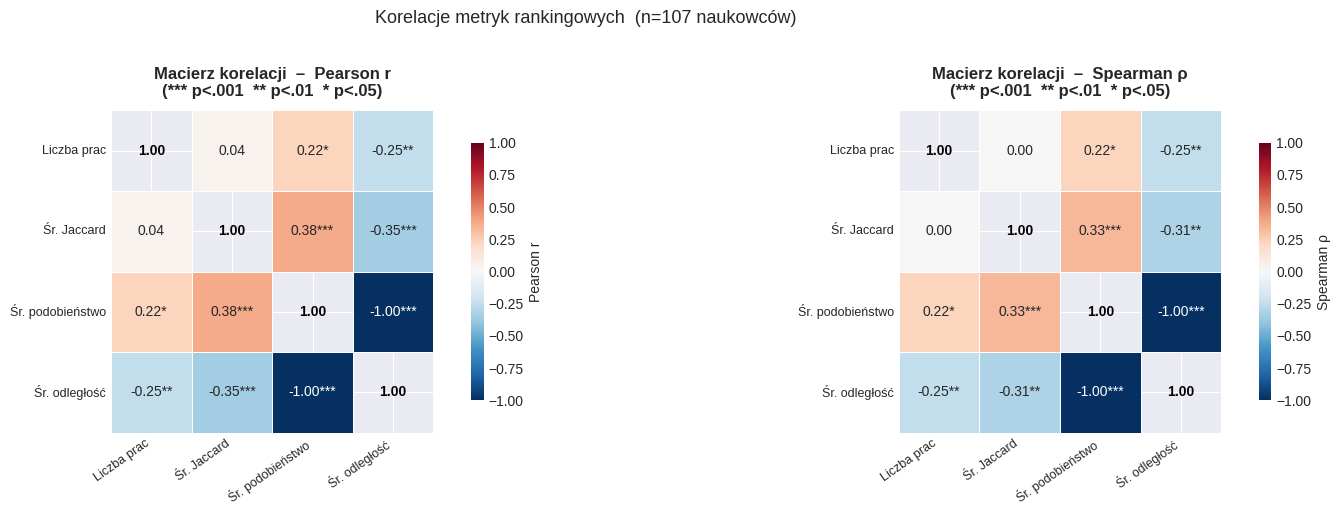

In [188]:

import seaborn as sns
from scipy import stats

# ── Kolumny numeryczne ────────────────────────────────────────────────────────
num_cols = ['Liczba prac', 'Śr. Jaccard', 'Śr. podobieństwo', 'Śr. odległość']
df_num   = df_ranking[num_cols]

# ── Pearson ───────────────────────────────────────────────────────────────────
pearson_r  = df_num.corr(method='pearson')
pearson_p  = pd.DataFrame(index=num_cols, columns=num_cols, dtype=float)
for c1 in num_cols:
    for c2 in num_cols:
        if c1 == c2:
            pearson_p.loc[c1, c2] = 0.0
        else:
            _, pval = stats.pearsonr(df_num[c1], df_num[c2])
            pearson_p.loc[c1, c2] = pval

# ── Spearman ──────────────────────────────────────────────────────────────────
spearman_r = df_num.corr(method='spearman')
spearman_p = pd.DataFrame(index=num_cols, columns=num_cols, dtype=float)
for c1 in num_cols:
    for c2 in num_cols:
        if c1 == c2:
            spearman_p.loc[c1, c2] = 0.0
        else:
            _, pval = stats.spearmanr(df_num[c1], df_num[c2])
            spearman_p.loc[c1, c2] = pval

# ── Etykiety z gwiazdkami istotności ─────────────────────────────────────────
def annot_matrix(r_df, p_df):
    """Łączy r z oznaczeniem istotności: *** p<.001, ** p<.01, * p<.05"""
    labels = pd.DataFrame(index=r_df.index, columns=r_df.columns)
    for c1 in r_df.index:
        for c2 in r_df.columns:
            r = r_df.loc[c1, c2]
            p = p_df.loc[c1, c2]
            stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            labels.loc[c1, c2] = f'{r:.2f}{stars}'
    return labels

annot_pearson  = annot_matrix(pearson_r,  pearson_p)
annot_spearman = annot_matrix(spearman_r, spearman_p)

# ── Wykres: 2 heatmapy obok siebie ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, r_df, annot, title in [
    (axes[0], pearson_r,  annot_pearson,  'Pearson r'),
    (axes[1], spearman_r, annot_spearman, 'Spearman ρ'),
]:
    mask = np.eye(len(num_cols), dtype=bool)
    sns.heatmap(
        r_df, ax=ax,
        annot=annot, fmt='',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, square=True,
        cbar_kws={'shrink': 0.8, 'label': title},
        mask=mask,
    )
    # Przekątna – "1.00"
    for i in range(len(num_cols)):
        ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center',
                fontsize=10, color='black', fontweight='bold')

    ax.set_title(f'Macierz korelacji  –  {title}\n(*** p<.001  ** p<.01  * p<.05)',
                 fontsize=12, fontweight='bold', pad=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.suptitle(f'Korelacje metryk rankingowych  (n={len(df_ranking)} naukowców)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()
